In [2]:
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)

mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

## 실습 문제 1: 3차 함수에 노이즈 추가 및 시각화

3차 함수 f(x) = x^3 - x^2 +3 를 생성하고, 여기에 무작위 노이즈를 추가하여 데이터를 만듭니다. 이후 Matplotlib을 사용하여 원본 함수와 노이즈가 추가된 데이터를 시각화합니다. 이는 데이터에 노이즈를 추가함으로써 모델의 일반화 성능을 향상시키는 효과를 이해하는 데 목적이 있습니다.

- **요구사항**:
    1. x 의 범위를 -5에서 5까지 100개의 점으로 생성하세요.
    2. 3차 함수 y=x^3 - x^2 +3 를 계산하세요.
    3. y 에 평균 0, 표준편차 10의 정규 분포 노이즈를 추가하여 증강된 데이터를 생성하세요. (np.random.normal)
    4. Matplotlib을 사용해 원본 함수를 선으로, 노이즈가 추가된 데이터를 산점도로 시각화하세요. (plt.plot, plt.scatter)

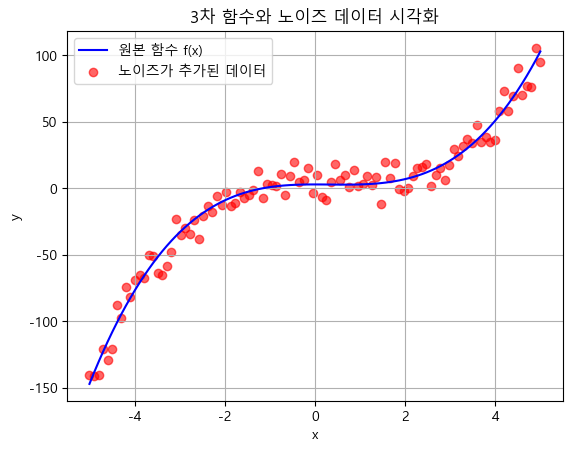

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. x의 범위
x = np.linspace(-5, 5, 100)

# 2. 3차 함수 생성
def f(x):
    return x**3 - x**2 + 3

y = f(x)

# 3. y에 평균 0, 표준편자 10의 정규 분포 노이즈 추가
noise = np.random.normal(0, 10, size=100)

y_noise = y + noise

# 4. 시각화
plt.plot(x, y, label='원본 함수 f(x)', color='blue')
plt.scatter(x, y_noise, label='노이즈가 추가된 데이터', color='red', alpha=0.6)
plt.legend()
plt.title('3차 함수와 노이즈 데이터 시각화')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

## 실습 문제 2: 소프트맥스 함수 (Softmax Function)
여러분은 이미지를 받아서 강아지인지 고양이인지 분류하는 간단한 인공지능 모델을 만들고 있다고 가정해 봅시다. 이 모델은 내부적으로 이미지에 대한 '강아지 점수($z_{dog}$)'와 '고양이 점수($z_{cat}$)'를 계산합니다. 점수가 높을수록 모델은 해당 클래스일 가능성이 높다고 판단합니다.

소프트맥스(Softmax) 함수는 이 '점수'들을 각 클래스(강아지, 고양이)에 대한 '확률'로 변환하는 중요한 역할을 합니다. 예를 들어, [강아지 점수=3, 고양이 점수=1] 이라면, 소프트맥스는 이를 [강아지일 확률=0.88, 고양이일 확률=0.12] 와 같이 변환하여 두 확률의 합이 1이 되도록 합니다.


**요구사항:**

1.  **입력 설정:**
    * '강아지 점수 ($z_{dog}$)'는 $-5$부터 $5$까지 $100$개의 구간으로 변화시킵니다.
    * '고양이 점수 ($z_{cat}$)'는 $1$로 고정합니다.
2.  **소프트맥스 계산:** NumPy를 사용하여 $z = [z_{dog}, z_{cat}]$ 에 대한 소프트맥스 확률 값을 계산합니다.

softmax(z)i=ezi∑jezj

여기서:

* 분자 $e^{z_i}$​는 클래스 i의 점수(z)에 지수 함수를 적용한 값입니다. i는 클래스 인덱스(dog=0, cat=1)를 나타냅니다

* 분모 $\sum_{j} e^{z_j}$​는 모든 클래스(dog와 cat)의 점수(z) 에 대한 지수 함수값의 합계입니다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 강아지 점수: 3 / 고양이 점수: 1
# 그럼 누가 더 가능성이 높을까? → 강아지
# 그런데 이 점수 3과 1을 그냥 확률처럼 쓰면 안됨: 합이 1이 아니니까 → 확률로 보기 어려움
# 음수도 가능하니까 → 확률로 해석 불가능
# 지수 함수는 큰 값을 더 키워주고, 작은 값은 작게 남김. 
# → 그래서 근소한 차이를 **확률처럼 “더 그럴듯한 값”**으로 만들어 줌
def softmax(z):
  e_z = np.exp(z)                 # 지수 함수 적용
  sum_e_z = np.sum(e_z, axis=1, keepdims=True)  # 각 행(row)마다 합 구해
  return e_z / sum_e_z            # 각 행의 원소를 합으로 나눠 → 확률

z_dog = np.linspace(-5, 5, 100)
z_cat =  np.ones_like(z_dog)
z = np.column_stack((z_dog, z_cat))

prob = softmax(z)
prob_dog, prob_cat = prob[:, 0], prob[:, 1]

plt.plot(z_dog, prob_dog, label='P(dog | z)')
plt.plot(z_dog, prob_cat, label='P(cat | z)', ls='--')
plt.xlabel('z_dog (Score for Dog)')
plt.ylabel('Probability')
plt.title('Softmax Probabilities vs. Dog Score (z_cat=1)')
plt.grid()
plt.legend()
plt.ylim(0, 1)

## 실습 문제 3: 드롭아웃

드롭아웃은 신경망 학습 시 과적합을 방지하기 위해 일부 뉴런을 무작위로 비활성화(0) 하는 기법입니다. 이 문제에서는 드롭아웃 마스크를 생성하여 가중치에 적용하고, 원본 가중치와 드롭아웃이 적용된 가중치에 특정 숫자를 곱하여 스케일링을 시뮬레이션합니다.

- **요구사항**:
    1. 5x5 크기의 가중치 w 를 np.random.randn(5, 5)로 생성하세요.
    2. dropout 함수를 정의하고, 드롭아웃 확률을 0.5로 설정하고, np.random.rand(5, 5)를 사용해 0과 1 사이의 난수를 생성하세요.
    3. 난수가 0.5 이상이면 1(활성화), 미만이면 0(비활성화)인 마스크를 만드세요.
    4. 원본 가중치와 드롭아웃이 적용된 가중치(가중치 * 마스크)를 계산하여 반환하세요.
    5. 원본 가중치와 드롭아웃이 적용된 가중치에 2를 곱한 결과를 출력하세요.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

w = np.random.randn(5,5)

# 2. 드롭아웃 함수 정의
def dropout(w, drop_prob=0.5):
# 3. 드롭아웃 마스크 생성 (0.5 이상이면 1, 아니면 0)
    mask = (np.random.rand(*w.shape) >= drop_prob).astype(float)
    
    # 4. 마스크를 가중치에 적용
    dropped_w = w * mask
    
    return mask, dropped_w

# 드롭아웃 적용
mask, dropped_w = dropout(w)

# 5. 결과 출력
print("🎯 원본 가중치:")
print(w)

print("\n🎯 드롭아웃 마스크 (0: 비활성화, 1: 활성화):")
print(mask)

print("\n🎯 드롭아웃 적용된 가중치:")
print(dropped_w)

print("\n🎯 원본 가중치 * 2:")
print(w * 2)

print("\n🎯 드롭아웃 적용된 가중치 * 2:")
print(dropped_w * 2)
    

🎯 원본 가중치:
[[ 1.00311095 -0.38249144  1.24102376  0.68209494 -0.76489102]
 [-0.17070933 -0.71246807  0.84978482 -1.58402746  0.46696138]
 [ 0.1898908   0.63198995 -0.9136057   0.59027634  0.64996845]
 [-1.75868775 -0.460374    1.64552049  0.83571067  0.42935094]
 [-1.78192643  1.5059416  -0.39166686  0.15921154  0.55270947]]

🎯 드롭아웃 마스크 (0: 비활성화, 1: 활성화):
[[1. 0. 0. 1. 1.]
 [1. 0. 1. 0. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0.]]

🎯 드롭아웃 적용된 가중치:
[[ 1.00311095 -0.          0.          0.68209494 -0.76489102]
 [-0.17070933 -0.          0.84978482 -0.          0.46696138]
 [ 0.          0.         -0.          0.59027634  0.64996845]
 [-0.         -0.          1.64552049  0.83571067  0.        ]
 [-0.          0.         -0.          0.          0.        ]]

🎯 원본 가중치 * 2:
[[ 2.00622189 -0.76498287  2.48204753  1.36418989 -1.52978204]
 [-0.34141866 -1.42493614  1.69956964 -3.16805492  0.93392277]
 [ 0.37978159  1.2639799  -1.8272114   1.18055267  1.2999369 ]
 [-3.51737549 -

## 실습 문제 4: 재고 관리

Inventory 클래스를 작성하세요. 이 클래스는 제품 이름과 재고 수량을 관리합니다. 제품을 입고(ipgo)시키거나 출고(chulgo)시키고, 특정 제품의 현재 재고를 확인하는 기능을 가져야 합니다. 재고 정보는 딕셔너리로 저장하며, 키는 제품 이름(문자열), 값은 재고 수량(정수)입니다.

**Methods:**

* __init__(): 제품 이름(str)을 키로, 재고 수량(int)을 값으로 가지는 빈 딕셔너리로 재고 정보를 초기화합니다. Inventory 인스턴스가 생성될 때, 재고는 비어 있는 상태로 시작합니다.

* ipgo(product_name: str, quantity: int): 지정된 product_name의 재고를 quantity만큼 증가시킵니다.

    * 만약 product_name이 재고에 이미 존재하면, 해당 제품의 재고 수량을 quantity만큼 증가시킵니다.
    * 만약 product_name이 재고에 존재하지 않으면, 새로운 제품으로 추가하고 초기 재고를 quantity로 설정합니다.
    * quantity는 양수여야 합니다. 0 또는 음수 quantity가 주어지면 아무 작업도 수행하지 않습니다.

* chulgo(product_name: str, quantity: int) -> bool: 지정된 product_name의 재고를 quantity만큼 감소시킵니다.

    다음 조건 중 하나라도 해당하면 재고는 변경되지 않고 False를 반환합니다:
        1. 제품이 존재하지 않음,
        2. quantity가 양수가 아님,
        3. quantity가 현재 재고보다 큼.
    성공적으로 재고를 감소시키면 True를 반환합니다.

* get_stock(product_name: str) -> int:
    지정된 product_name의 현재 재고 수량을 반환합니다. 제품이 재고에 존재하지 않으면 0을 반환합니다.

In [6]:
class Inventory:
  def __init__(self):
        # 모든 제품 재고를 저장할 딕셔너리
        self.stock = {}

  def ipgo(self, product_name: str, quantity: int):
      if quantity <= 0:
          return  # 0이나 음수는 무시
      if product_name in self.stock:
          self.stock[product_name] += quantity
      else:
          self.stock[product_name] = quantity

  def chulgo(self, product_name: str, quantity: int) -> bool:
      if (
          product_name not in self.stock or  # 재고에 없거나
          quantity <= 0 or                   # 수량이 0 이하이거나
          self.stock[product_name] < quantity  # 재고보다 더 많이 출고하려는 경우
      ):
          return False  # 실패
      self.stock[product_name] -= quantity
      return True  # 성공

  def get_stock(self, product_name: str) -> int:
      return self.stock.get(product_name, 0)  # 없으면 0 반환

input_data_inventory = [
  [
    ("ipgo", "Galaxy S25 Ultra", 50),
    ("ipgo", "AirPods Pro 3", 100),
    ("ipgo", "Galaxy S25 Ultra", 10),
    ("ipgo", "AirPods Pro 3", 20),
    ("ipgo", "Pixel Watch 3", 30),
    ("ipgo", "Pixel Watch 3", 0)
  ],
  [
    ("ipgo", "MacBook Air M4", 25),
    ("chulgo", "MacBook Air M4", 10),
    ("chulgo", "MacBook Air M4", 20),
    ("chulgo", "iPad Pro M4", 5),
    ("chulgo", "MacBook Air M4", -5),
    ("ipgo", "iPad Pro M4", 10),
    ("chulgo", "MacBook Air M4", 15)
  ]
]

expected_inventory_states = [
  {"Galaxy S25 Ultra": 60, "AirPods Pro 3": 120, "Pixel Watch 3": 30},
  {"MacBook Air M4": 0, "iPad Pro M4": 10}
]

for data_set, expected_state in zip(input_data_inventory, expected_inventory_states):
  inventory = Inventory()
  for action, product_name, quantity in data_set:
    if action == "ipgo":
      inventory.ipgo(product_name, quantity)
    elif action == "chulgo":
      inventory.chulgo(product_name, quantity)
  assert inventory.stock == expected_state, f"Test Failed! Expected {expected_state}, Got {inventory.stock}"

## 실습 문제 5: 간단한 신경망

SimpleNeuralNetwork 에 필요한 계층 클래스들(Dense, ReLU, Softmax)을 구현하세요. 이 신경망은 입력 값을 받아 순전파(forward propagation)만 수행하는 간단한 구조를 가집니다. 각 계층은 독립적인 클래스로 구현하고, 이들을 조합하여 전체 신경망을 만들어야 합니다.

## 구현할 클래스들:

### 1. Dense 클래스
**Methods:**
- __init__(input_size: int, output_size: int): 입력 크기와 출력 크기를 받아 가중치(weights)와 편향(bias)을 초기화합니다. 가중치는 He 방법으로 초기화하고, 편향은 0으로 초기화합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 대해 선형 변환(inputs @ weights + bias)을 수행하고 결과를 반환합니다.

### 2. ReLU 클래스
**Methods:**
- __init__(): 초기화 메서드입니다. 필요한 경우 내부 상태를 설정합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 ReLU 활성화 함수를 적용하고 결과를 반환합니다. (np.maximum 활용)

### 3. Softmax 클래스
**Methods:**
- __init__(): 초기화 메서드입니다. 필요한 경우 내부 상태를 설정합니다.
- forward(inputs: np.ndarray) -> np.ndarray: 입력 데이터에 Softmax 함수를 적용하여 각 클래스에 대한 확률 분포를 반환합니다.

## 요구사항:
1. NumPy 라이브러리를 사용하여 모든 계산을 수행합니다.
2. 계층 클래스들은 각각 독립적으로 동작해야 하며, 다른 계층과의 인터페이스는 forward 메서드로 통일합니다.

In [ ]:
class Dense:
  def __init__(self, input_size, output_size, init='he'):
    pass

  def forward(self, inputs):
    pass

class ReLU:
  def __init__(self):
    pass

  def forward(self, inputs):
    pass

class Softmax:
  def __init__(self):
    pass

  def forward(self, inputs):
    pass

class SimpleNeuralNetwork:
  def __init__(self, input_size, hidden_size, output_size):
    self.dense1 = Dense(input_size, hidden_size)
    self.relu = ReLU()
    self.dense2 = Dense(hidden_size, output_size)
    self.softmax = Softmax()

  def forward(self, inputs):
    x = self.dense1.forward(inputs)
    x = self.relu.forward(x)
    x = self.dense2.forward(x)
    x = self.softmax.forward(x)
    return x

np.random.seed(0)

X = np.array([
  [0, 0],
  [0, 1],
  [1, 0],
  [1, 1]
])

network = SimpleNeuralNetwork(2, 4, 2)
prob = network.forward(X)

print("입력:", X)
print("\n출력 확률:", prob)
print("\n확률 합:", np.sum(prob, axis=1))

### 실습 문제 8: 파일실습
* 파일에서 숫자 데이터를 처리하고 합계, 평균, 최소값, 최대값 및 중앙값과 같은 기본 통계를 계산하는 메서드를 제공하는 FileProcessor 클래스를 작성하세요.

* FileProcessor 클래스
생성자: FileProcessor 객체를 초기화합니다. 파일 이름을 입력으로 받아 저장하고, 이후에 파일에서 읽어온 숫자 데이터를 저장할 빈 리스트 self.data를 초기화합니다. 힌트: 이 메서드는 파일을 읽고 처리할 준비를 합니다. 파일 경로는 저장되지만, 데이터는 다른 메서드에서 요청할 때까지 로드되지 않습니다.

* read_file(self): 파일에서 데이터를 읽습니다. 파일을 읽기 모드로 열고, 각 줄에서 불필요한 문자를 제거한 후 데이터를 실수로 변환합니다. 이 처리된 데이터를 self.data에 저장합니다. 힌트: 이 메서드를 사용하여 필요한 경우에만 데이터를 지연 로드합니다. FileNotFoundError 및 ValueError와 같은 파일 관련 오류를 처리하여 파일 읽기가 견고하게 이루어지도록 합니다.

* sum(self): 숫자 데이터의 합계를 계산합니다. 결과를 소수점 한 자리까지 반올림하여 반환합니다. 힌트: 계산을 수행하기 전에 파일이 읽혔는지 확인하세요. 내장된 sum() 함수를 사용하여 코드를 간소화할 수 있습니다. 빈 파일이 있을 수 있으므로 _read_file이 성공적으로 호출된 경우에만 이 메서드가 제대로 작동합니다.

* average(self): 숫자 데이터의 평균(산술 평균)을 계산합니다. 필요한 경우 _read_file을 호출하여 데이터가 사용 가능한지 확인합니다. 데이터가 없을 경우 ZeroDivisionError를 발생시킵니다. 힌트: 평균은 데이터의 합계를 항목 수로 나눈 값입니다. 나누기를 수행하기 전에 항목이 있는지 확인하여 0으로 나누는 오류를 방지하세요.

* min(self): 데이터셋에서 최소값을 계산하고 반환합니다. 아직 파일을 읽지 않았다면 파일을 읽어 데이터를 확인합니다. 데이터가 없을 경우 ValueError를 발생시킵니다. 힌트: Python의 내장 min() 함수를 사용하여 최소값을 찾습니다. 데이터가 없는 경우 적절하게 예외를 발생시켜야 합니다.

* max(self): 데이터셋에서 최대값을 계산하고 반환합니다. 필요한 경우 데이터를 읽고, 데이터가 비어 있으면 ValueError를 발생시킵니다. 힌트: calc_min()과 유사하게 구현되지만, max()를 사용하여 가장 큰 숫자를 반환합니다.

* median(self): 숫자 데이터의 중앙값을 계산하고 반환합니다. 데이터를 정렬한 후 중앙값을 계산합니다. 데이터 포인트 수가 홀수인 경우 중간값을 반환하고, 짝수인 경우 두 중간값의 평균을 반환합니다. 힌트: 데이터를 읽은 후 정렬하여 중앙값을 계산합니다. 데이터 길이가 짝수일 경우 중앙값은 두 중간 숫자의 평균이고, 홀수일 경우 중앙값은 중간 숫자입니다.

* save(self, output_filename): 모든 통계치(합계, 평균, 최소값, 최대값, 중앙값)를 계산하고, 이를 output_filename으로 지정된 새로운 파일에 저장합니다.

저장 예)

합계: 7.4
평균: 2.5
최소값: 1.5
최대값: 3.2
중앙값: 2.7

In [14]:
from pathlib import Path



class FileProcessor:
    def __init__(self, filename):
        self.filename = Path(filename)
        self.data = []
    
    # 파일을 읽기 모드로 열고, 
    # 각 줄에서 불필요한 문자를 제거한 후 데이터를 실수로 변환
    # 처리된 데이터를 self.data에 저장
    def read_file(self):
        try:
            with self.filename.open(encoding='utf-8') as file:
                self.data = [float(line.strip()) for line in file if line.strip()]
        except FileNotFoundError:
            print(f"파일 찾기 오류")
        except ValueError:
            print("파일 내용 오류")
    
    def sum(self):
        if not self.data:
            self.read_file()
        return round(sum(self.data), 1)
    
    # 숫자 데이터의 평균(산술 평균)을 계산
    def average(self):
        if not self.data:
            self.read_file()
        if not self.data:
            raise ZeroDivisionError("데이터 없음")
        return round(sum(self.data) / len(self.data), 1)
    
    # 최소값을 계산하고 반환
    def min(self):
        if not self.data:
            self.read_file()
        if not self.data:
            raise ValueError("데이터가 없습니다.")
        return min(self.data)
    
    # 최대값을 계산하고 반환
    def max(self):
        if not self.data:
            self.read_file()
        if not self.data:
            raise ValueError("데이터가 없습니다.")
        return max(self.data)
    
    # 데이터를 정렬한 후 중앙값을 계산 
    # 데이터 포인트 수가 홀수인 경우 중간값을 반환
    # 짝수인 경우 두 중간값의 평균을 반환
    def median(self):
        if not self.data:
            self.read_file()
        if not self.data:
            raise ValueError("데이터가 없습니다.")
        sorted_data = sorted(self.data)
        n = len(sorted_data)
        mid = n // 2
        if n % 2 == 1:
            return sorted_data[mid]
        else:
            return round((sorted_data[mid - 1] + sorted_data[mid]) / 2, 1)
    
    def save(self, output_filename):
        output_file = Path(output_filename)
        
        try:
            with output_file.open('w', encoding='utf-8') as f:
                f.write(f"합계 : {self.sum()}\n")
                f.write(f"평균 : {self.average()}\n")
                f.write(f"최소값 : {self.min()}\n")
                f.write(f"최대값 : {self.max()}\n")
                f.write(f"중앙값 : {self.median()}\n")
            
        except Exception:
            print( "오류 발생")

fp = FileProcessor("Numbers.txt")
fp.save("summary.txt")
